In [1]:
import pandas as pd
import requests

In [3]:
url = "https://api.github.com/search/repositories?q=machine+learning&sort=stars&order=desc&per_page=100"

response = requests.get(url)

data = response.json()

In [5]:
data.keys()

dict_keys(['total_count', 'incomplete_results', 'items'])

In [7]:
data["items"][0]

{'id': 45717250,
 'node_id': 'MDEwOlJlcG9zaXRvcnk0NTcxNzI1MA==',
 'name': 'tensorflow',
 'full_name': 'tensorflow/tensorflow',
 'private': False,
 'owner': {'login': 'tensorflow',
  'id': 15658638,
  'node_id': 'MDEyOk9yZ2FuaXphdGlvbjE1NjU4NjM4',
  'avatar_url': 'https://avatars.githubusercontent.com/u/15658638?v=4',
  'gravatar_id': '',
  'url': 'https://api.github.com/users/tensorflow',
  'html_url': 'https://github.com/tensorflow',
  'followers_url': 'https://api.github.com/users/tensorflow/followers',
  'following_url': 'https://api.github.com/users/tensorflow/following{/other_user}',
  'gists_url': 'https://api.github.com/users/tensorflow/gists{/gist_id}',
  'starred_url': 'https://api.github.com/users/tensorflow/starred{/owner}{/repo}',
  'subscriptions_url': 'https://api.github.com/users/tensorflow/subscriptions',
  'organizations_url': 'https://api.github.com/users/tensorflow/orgs',
  'repos_url': 'https://api.github.com/users/tensorflow/repos',
  'events_url': 'https://api.git

In [9]:
df = pd.DataFrame(data["items"])

In [13]:
df.head()

,id,node_id,name,full_name,private,owner,html_url,description,fork,url,...,web_commit_signoff_required,has_pull_requests,pull_request_creation_policy,topics,visibility,forks,open_issues,watchers,default_branch,score
0,45717250,MDEwOlJlcG9zaXRvcnk0NTcxNzI1MA==,tensorflow,tensorflow/tensorflow,False,"{'login': 'tensorflow', 'id': 15658638, 'node_...",https://github.com/tensorflow/tensorflow,An Open Source Machine Learning Framework for ...,False,https://api.github.com/repos/tensorflow/tensor...,...,False,True,all,"[deep-learning, deep-neural-networks, distribu...",public,75767,2939,196650,master,1.0
1,155220641,MDEwOlJlcG9zaXRvcnkxNTUyMjA2NDE=,transformers,huggingface/transformers,False,"{'login': 'huggingface', 'id': 25720743, 'node...",https://github.com/huggingface/transformers,🤗 Transformers: the model-definition framework...,False,https://api.github.com/repos/huggingface/trans...,...,False,True,all,"[audio, deep-learning, deepseek, gemma, glm, h...",public,34084,2319,163225,main,1.0
2,343965132,MDEwOlJlcG9zaXRvcnkzNDM5NjUxMzI=,ML-For-Beginners,microsoft/ML-For-Beginners,False,"{'login': 'microsoft', 'id': 6154722, 'node_id...",https://github.com/microsoft/ML-For-Beginners,"12 weeks, 26 lessons, 52 quizzes, classic Mach...",False,https://api.github.com/repos/microsoft/ML-For-...,...,False,True,all,"[data-science, education, machine-learning, ma...",public,21747,7,88854,main,1.0
3,145553672,MDEwOlJlcG9zaXRvcnkxNDU1NTM2NzI=,funNLP,fighting41love/funNLP,False,"{'login': 'fighting41love', 'id': 11475294, 'n...",https://github.com/fighting41love/funNLP,中英文敏感词、语言检测、中外手机/电话归属地/运营商查询、名字推断性别、手机号抽取、身份证抽...,False,https://api.github.com/repos/fighting41love/fu...,...,False,True,all,[],public,15265,52,82183,master,1.0
4,21872392,MDEwOlJlcG9zaXRvcnkyMTg3MjM5Mg==,awesome-machine-learning,josephmisiti/awesome-machine-learning,False,"{'login': 'josephmisiti', 'id': 246302, 'node_...",https://github.com/josephmisiti/awesome-machin...,A curated list of awesome Machine Learning fra...,False,https://api.github.com/repos/josephmisiti/awes...,...,False,True,all,[],public,15582,20,73830,master,1.0


In [14]:
df.columns

Index(['id', 'node_id', 'name', 'full_name', 'private', 'owner', 'html_url',
       'description', 'fork', 'url', 'forks_url', 'keys_url',
       'collaborators_url', 'teams_url', 'hooks_url', 'issue_events_url',
       'events_url', 'assignees_url', 'branches_url', 'tags_url', 'blobs_url',
       'git_tags_url', 'git_refs_url', 'trees_url', 'statuses_url',
       'languages_url', 'stargazers_url', 'contributors_url',
       'subscribers_url', 'subscription_url', 'commits_url', 'git_commits_url',
       'comments_url', 'issue_comment_url', 'contents_url', 'compare_url',
       'merges_url', 'archive_url', 'downloads_url', 'issues_url', 'pulls_url',
       'milestones_url', 'notifications_url', 'labels_url', 'releases_url',
       'deployments_url', 'created_at', 'updated_at', 'pushed_at', 'git_url',
       'ssh_url', 'clone_url', 'svn_url', 'homepage', 'size',
       'stargazers_count', 'watchers_count', 'language', 'has_issues',
       'has_projects', 'has_downloads', 'has_wiki', 'has

In [16]:
df = df[
    [
        "name",
        "owner",
        "language",
        "stargazers_count",
        "forks_count",
        "watchers_count",
        "open_issues_count",
        "created_at",
        "updated_at",
        "license"
    ]
]

In [17]:
df["owner"] = df["owner"].apply(lambda x: x["login"] if pd.notnull(x) else None)

In [18]:
df["license"] = df["license"].apply(lambda x: x["name"] if isinstance(x, dict) else "No License")

In [19]:
df.head()

,name,owner,language,stargazers_count,forks_count,watchers_count,open_issues_count,created_at,updated_at,license
0,tensorflow,tensorflow,C++,196650,75767,196650,2939,2015-11-07T01:19:20Z,2026-08-01T21:01:19Z,Apache License 2.0
1,transformers,huggingface,Python,163225,34084,163225,2319,2018-10-29T13:56:00Z,2026-08-01T21:41:31Z,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,88854,21747,88854,7,2021-03-03T01:34:05Z,2026-08-01T21:56:08Z,MIT License
3,funNLP,fighting41love,Python,82183,15265,82183,52,2018-08-21T11:20:39Z,2026-08-01T18:48:50Z,No License
4,awesome-machine-learning,josephmisiti,Python,73830,15582,73830,20,2014-07-15T19:11:19Z,2026-08-01T21:46:12Z,Other


In [20]:
df.isnull().sum()

,0
name,0
owner,0
language,23
stargazers_count,0
forks_count,0
watchers_count,0
open_issues_count,0
created_at,0
updated_at,0
license,0


In [21]:
df = df.drop_duplicates()

In [22]:
df["created_at"] = pd.to_datetime(df["created_at"])
df["updated_at"] = pd.to_datetime(df["updated_at"])

In [23]:
df.rename(columns={
    "stargazers_count": "stars",
    "forks_count": "forks",
    "watchers_count": "watchers",
    "open_issues_count": "open_issues",
    "created_at": "created_date",
    "updated_at": "updated_date"
}, inplace=True)

In [24]:
df.head()

,name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
0,tensorflow,tensorflow,C++,196650,75767,196650,2939,2015-11-07 01:19:20+00:00,2026-08-01 21:01:19+00:00,Apache License 2.0
1,transformers,huggingface,Python,163225,34084,163225,2319,2018-10-29 13:56:00+00:00,2026-08-01 21:41:31+00:00,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,88854,21747,88854,7,2021-03-03 01:34:05+00:00,2026-08-01 21:56:08+00:00,MIT License
3,funNLP,fighting41love,Python,82183,15265,82183,52,2018-08-21 11:20:39+00:00,2026-08-01 18:48:50+00:00,No License
4,awesome-machine-learning,josephmisiti,Python,73830,15582,73830,20,2014-07-15 19:11:19+00:00,2026-08-01 21:46:12+00:00,Other


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype              
---  ------        --------------  -----              
 0   name          100 non-null    object             
 1   owner         100 non-null    object             
 2   language      77 non-null     object             
 3   stars         100 non-null    int64              
 4   forks         100 non-null    int64              
 5   watchers      100 non-null    int64              
 6   open_issues   100 non-null    int64              
 7   created_date  100 non-null    datetime64[ns, UTC]
 8   updated_date  100 non-null    datetime64[ns, UTC]
 9   license       100 non-null    object             
dtypes: datetime64[ns, UTC](2), int64(4), object(4)
memory usage: 7.9+ KB


In [26]:
df["language"] = df["language"].fillna("Unknown")

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype              
---  ------        --------------  -----              
 0   name          100 non-null    object             
 1   owner         100 non-null    object             
 2   language      100 non-null    object             
 3   stars         100 non-null    int64              
 4   forks         100 non-null    int64              
 5   watchers      100 non-null    int64              
 6   open_issues   100 non-null    int64              
 7   created_date  100 non-null    datetime64[ns, UTC]
 8   updated_date  100 non-null    datetime64[ns, UTC]
 9   license       100 non-null    object             
dtypes: datetime64[ns, UTC](2), int64(4), object(4)
memory usage: 7.9+ KB


In [28]:
df.to_csv("github_projects.csv", index=False)

In [29]:
df2 = pd.read_csv("github_projects.csv")
df2.head()

,name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
0,tensorflow,tensorflow,C++,196650,75767,196650,2939,2015-11-07 01:19:20+00:00,2026-08-01 21:01:19+00:00,Apache License 2.0
1,transformers,huggingface,Python,163225,34084,163225,2319,2018-10-29 13:56:00+00:00,2026-08-01 21:41:31+00:00,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,88854,21747,88854,7,2021-03-03 01:34:05+00:00,2026-08-01 21:56:08+00:00,MIT License
3,funNLP,fighting41love,Python,82183,15265,82183,52,2018-08-21 11:20:39+00:00,2026-08-01 18:48:50+00:00,No License
4,awesome-machine-learning,josephmisiti,Python,73830,15582,73830,20,2014-07-15 19:11:19+00:00,2026-08-01 21:46:12+00:00,Other


In [30]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   name          100 non-null    object
 1   owner         100 non-null    object
 2   language      100 non-null    object
 3   stars         100 non-null    int64 
 4   forks         100 non-null    int64 
 5   watchers      100 non-null    int64 
 6   open_issues   100 non-null    int64 
 7   created_date  100 non-null    object
 8   updated_date  100 non-null    object
 9   license       100 non-null    object
dtypes: int64(4), object(6)
memory usage: 7.9+ KB


# **Task 2** - **Part 1**

In [34]:
import sqlite3
conn = sqlite3.connect("github_projects.db")
df2.to_sql("Repositories", conn, if_exists="replace", index=False)

100

In [35]:
pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)

,name
0,Repositories


In [36]:
pd.read_sql("SELECT * FROM Repositories LIMIT 5;", conn)

,name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
0,tensorflow,tensorflow,C++,196650,75767,196650,2939,2015-11-07 01:19:20+00:00,2026-08-01 21:01:19+00:00,Apache License 2.0
1,transformers,huggingface,Python,163225,34084,163225,2319,2018-10-29 13:56:00+00:00,2026-08-01 21:41:31+00:00,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,88854,21747,88854,7,2021-03-03 01:34:05+00:00,2026-08-01 21:56:08+00:00,MIT License
3,funNLP,fighting41love,Python,82183,15265,82183,52,2018-08-21 11:20:39+00:00,2026-08-01 18:48:50+00:00,No License
4,awesome-machine-learning,josephmisiti,Python,73830,15582,73830,20,2014-07-15 19:11:19+00:00,2026-08-01 21:46:12+00:00,Other


# **Task 2** - **Part 2**

In [37]:
pd.read_sql("""
SELECT *
FROM Repositories
WHERE stars > 10000;
""", conn)

,name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
0,tensorflow,tensorflow,C++,196650,75767,196650,2939,2015-11-07 01:19:20+00:00,2026-08-01 21:01:19+00:00,Apache License 2.0
1,transformers,huggingface,Python,163225,34084,163225,2319,2018-10-29 13:56:00+00:00,2026-08-01 21:41:31+00:00,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,88854,21747,88854,7,2021-03-03 01:34:05+00:00,2026-08-01 21:56:08+00:00,MIT License
3,funNLP,fighting41love,Python,82183,15265,82183,52,2018-08-21 11:20:39+00:00,2026-08-01 18:48:50+00:00,No License
4,awesome-machine-learning,josephmisiti,Python,73830,15582,73830,20,2014-07-15 19:11:19+00:00,2026-08-01 21:46:12+00:00,Other
...,...,...,...,...,...,...,...,...,...,...
65,machine-learning-systems-design,chiphuyen,HTML,10474,1618,10474,11,2019-11-24 23:16:28+00:00,2026-08-01 07:39:37+00:00,No License
66,Machine-Learning,Jack-Cherish,Python,10358,5073,10358,7,2017-03-25 07:32:37+00:00,2026-08-01 16:39:50+00:00,No License
67,3D-Machine-Learning,timzhang642,Unknown,10189,1800,10189,21,2017-08-12 15:20:54+00:00,2026-08-01 17:33:10+00:00,No License
68,tpot,EpistasisLab,Jupyter Notebook,10048,1563,10048,310,2015-11-03 21:08:40+00:00,2026-07-31 19:02:10+00:00,GNU Lesser General Public License v3.0


In [38]:
pd.read_sql("""
SELECT *
FROM Repositories
WHERE name LIKE '%Machine%';
""", conn)

,name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
0,awesome-machine-learning,josephmisiti,Python,73830,15582,73830,20,2014-07-15 19:11:19+00:00,2026-08-01 21:46:12+00:00,Other
1,500-AI-Machine-learning-Deep-learning-Computer...,ashishpatel26,Unknown,35871,7395,35871,67,2021-01-02 12:08:37+00:00,2026-08-01 21:46:16+00:00,No License
2,machine-learning-for-software-engineers,ZuzooVn,Unknown,28846,6152,28846,32,2016-10-09 21:20:25+00:00,2026-08-01 02:17:36+00:00,Creative Commons Attribution Share Alike 4.0 I...
3,homemade-machine-learning,trekhleb,Jupyter Notebook,24722,4191,24722,31,2018-11-01 04:34:19+00:00,2026-08-01 08:56:43+00:00,MIT License
4,awesome-production-machine-learning,EthicalML,Unknown,20812,2589,20812,31,2018-08-15 14:28:41+00:00,2026-08-01 08:39:59+00:00,MIT License
5,machine-learning-for-trading,stefan-jansen,Jupyter Notebook,20220,5470,20220,0,2018-05-09 12:33:08+00:00,2026-08-01 21:22:20+00:00,MIT License
6,stanford-cs-229-machine-learning,afshinea,Unknown,20012,4233,20012,20,2018-08-04 23:01:00+00:00,2026-08-01 21:46:21+00:00,MIT License
7,Machine-Learning-Tutorials,ujjwalkarn,Unknown,18058,3971,18058,47,2015-09-12 14:51:38+00:00,2026-08-01 19:07:34+00:00,Creative Commons Zero v1.0 Universal
8,machine-learning-zoomcamp,DataTalksClub,Jupyter Notebook,13834,3082,13834,1,2020-04-17 04:29:23+00:00,2026-08-01 21:37:03+00:00,No License
9,machine-learning-interview,khangich,Unknown,12750,2041,12750,9,2020-08-11 06:26:32+00:00,2026-08-01 05:48:23+00:00,No License


In [39]:
pd.read_sql("""
SELECT name, stars
FROM Repositories
ORDER BY stars DESC
LIMIT 10;
""", conn)

,name,stars
0,tensorflow,196650
1,transformers,163225
2,ML-For-Beginners,88854
3,funNLP,82183
4,awesome-machine-learning,73830
5,scikit-learn,66851
6,gradio,43264
7,500-AI-Machine-learning-Deep-learning-Computer...,35871
8,C-Plus-Plus,34538
9,netron,33290


In [40]:
pd.read_sql("""
SELECT COUNT(*) AS total_repositories
FROM Repositories;
""", conn)

,total_repositories
0,100


In [41]:
pd.read_sql("""
SELECT AVG(stars) AS average_stars
FROM Repositories;
""", conn)

,average_stars
0,20730.56


In [42]:
pd.read_sql("""
SELECT language, COUNT(*) AS repository_count
FROM Repositories
GROUP BY language;
""", conn)

,language,repository_count
0,C,1
1,C#,2
2,C++,12
3,CSS,1
4,Go,3
5,HTML,2
6,Java,1
7,JavaScript,3
8,Jupyter Notebook,19
9,Markdown,1


In [43]:
pd.read_sql("""
SELECT language, COUNT(*) AS repository_count
FROM Repositories
GROUP BY language
HAVING COUNT(*) > 5;
""", conn)

,language,repository_count
0,C++,12
1,Jupyter Notebook,19
2,Python,30
3,Unknown,23


AND

In [44]:
pd.read_sql("""
SELECT *
FROM Repositories
WHERE stars > 50000
AND language = 'Python';
""", conn)

,name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
0,transformers,huggingface,Python,163225,34084,163225,2319,2018-10-29 13:56:00+00:00,2026-08-01 21:41:31+00:00,Apache License 2.0
1,funNLP,fighting41love,Python,82183,15265,82183,52,2018-08-21 11:20:39+00:00,2026-08-01 18:48:50+00:00,No License
2,awesome-machine-learning,josephmisiti,Python,73830,15582,73830,20,2014-07-15 19:11:19+00:00,2026-08-01 21:46:12+00:00,Other
3,scikit-learn,scikit-learn,Python,66851,27249,66851,2111,2010-08-17 09:43:38+00:00,2026-08-01 20:20:22+00:00,"BSD 3-Clause ""New"" or ""Revised"" License"


OR

In [45]:
pd.read_sql("""
SELECT *
FROM Repositories
WHERE language = 'Python'
OR language = 'C++';
""", conn)

,name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
0,tensorflow,tensorflow,C++,196650,75767,196650,2939,2015-11-07 01:19:20+00:00,2026-08-01 21:01:19+00:00,Apache License 2.0
1,transformers,huggingface,Python,163225,34084,163225,2319,2018-10-29 13:56:00+00:00,2026-08-01 21:41:31+00:00,Apache License 2.0
2,funNLP,fighting41love,Python,82183,15265,82183,52,2018-08-21 11:20:39+00:00,2026-08-01 18:48:50+00:00,No License
3,awesome-machine-learning,josephmisiti,Python,73830,15582,73830,20,2014-07-15 19:11:19+00:00,2026-08-01 21:46:12+00:00,Other
4,scikit-learn,scikit-learn,Python,66851,27249,66851,2111,2010-08-17 09:43:38+00:00,2026-08-01 20:20:22+00:00,"BSD 3-Clause ""New"" or ""Revised"" License"
5,gradio,gradio-app,Python,43264,3567,43264,206,2018-12-19 08:24:04+00:00,2026-08-01 21:47:48+00:00,Apache License 2.0
6,C-Plus-Plus,TheAlgorithms,C++,34538,7843,34538,42,2016-07-16 10:19:45+00:00,2026-08-01 06:15:03+00:00,MIT License
7,ML-From-Scratch,eriklindernoren,Python,32400,5424,32400,76,2017-02-05 12:11:23+00:00,2026-08-01 19:18:24+00:00,MIT License
8,linkedin-skill-assessments-quizzes,Ebazhanov,Python,28805,12919,28805,21,2019-07-13 19:52:56+00:00,2026-08-01 09:31:36+00:00,GNU Affero General Public License v3.0
9,cs249r_book,harvard-edge,Python,27679,3418,27679,37,2023-09-06 19:31:06+00:00,2026-08-01 19:43:31+00:00,Other


NOT

In [46]:
pd.read_sql("""
SELECT *
FROM Repositories
WHERE NOT language = 'Python';
""", conn)

,name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
0,tensorflow,tensorflow,C++,196650,75767,196650,2939,2015-11-07 01:19:20+00:00,2026-08-01 21:01:19+00:00,Apache License 2.0
1,ML-For-Beginners,microsoft,Jupyter Notebook,88854,21747,88854,7,2021-03-03 01:34:05+00:00,2026-08-01 21:56:08+00:00,MIT License
2,500-AI-Machine-learning-Deep-learning-Computer...,ashishpatel26,Unknown,35871,7395,35871,67,2021-01-02 12:08:37+00:00,2026-08-01 21:46:16+00:00,No License
3,C-Plus-Plus,TheAlgorithms,C++,34538,7843,34538,42,2016-07-16 10:19:45+00:00,2026-08-01 06:15:03+00:00,MIT License
4,netron,lutzroeder,JavaScript,33290,3175,33290,18,2010-12-26 12:53:43+00:00,2026-08-01 16:59:55+00:00,MIT License
...,...,...,...,...,...,...,...,...,...,...
65,Machine-Learning-Specialization-Coursera,greyhatguy007,Jupyter Notebook,7702,3719,7702,25,2022-06-16 15:31:02+00:00,2026-08-01 10:32:40+00:00,MIT License
66,Learn_Machine_Learning_in_3_Months,llSourcell,Unknown,7610,2312,7610,19,2018-03-02 10:59:53+00:00,2026-08-01 03:01:15+00:00,No License
67,awesome-youtubers,JoseDeFreitas,Markdown,7587,489,7587,3,2020-08-25 14:18:15+00:00,2026-08-01 04:02:13+00:00,Creative Commons Zero v1.0 Universal
68,h2o-3,h2oai,Jupyter Notebook,7502,2028,7502,2878,2014-03-03 16:08:07+00:00,2026-08-01 00:19:06+00:00,Apache License 2.0


# **Task 2 - Part 3**

**Bar** **Chart**

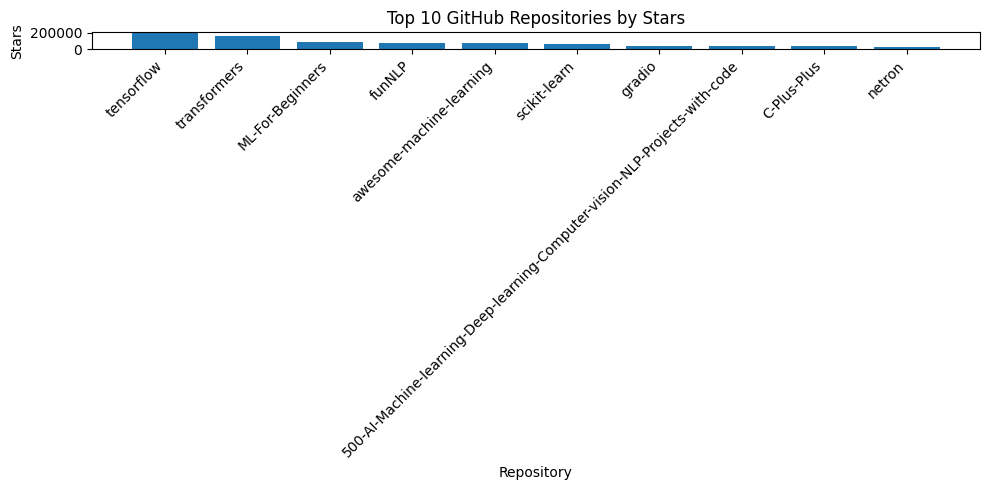

In [47]:
import matplotlib.pyplot as plt

top10 = pd.read_sql("""
SELECT name, stars
FROM Repositories
ORDER BY stars DESC
LIMIT 10;
""", conn)

plt.figure(figsize=(10,5))
plt.bar(top10["name"], top10["stars"])
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 GitHub Repositories by Stars")
plt.xlabel("Repository")
plt.ylabel("Stars")
plt.tight_layout()
plt.show()

**Line Chart**

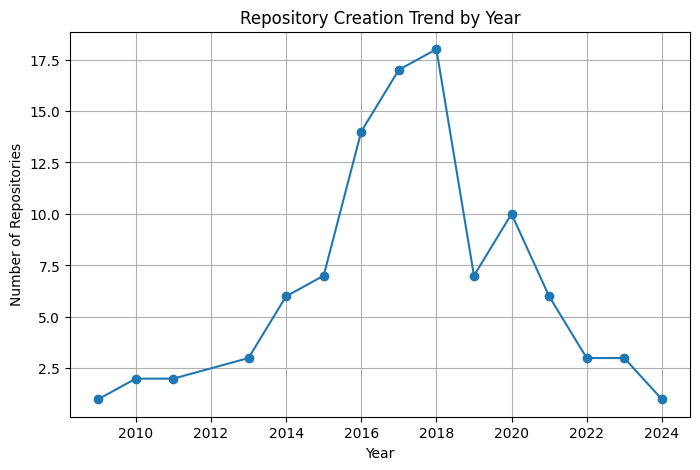

In [48]:
df2["created_date"] = pd.to_datetime(df2["created_date"])

trend = df2.groupby(df2["created_date"].dt.year).size()

plt.figure(figsize=(8,5))
plt.plot(trend.index, trend.values, marker="o")
plt.title("Repository Creation Trend by Year")
plt.xlabel("Year")
plt.ylabel("Number of Repositories")
plt.grid(True)
plt.show()